<h3> Method with weighted means for finding the centeroid embedding of a document, silhouette method for finding the K number of clusters, and K-Means for clustering. </h3>

<h5> Imports </h5>

In [1]:
import json
import glob
import os

import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from kneed import KneeLocator

import shutil

<h5> To avoid the re-embedding from scratch, we just pick-up the embedding results from the files </h5>

In [ ]:
# Read all JSON files from embeddings folder
embeddings_dir = os.path.join("data_output", "embeddings")
files_dir = "data"
embeddings_files = glob.glob(os.path.join(embeddings_dir, "*.json"))

all_results = []

print(f"Found {len(embeddings_files)} JSON files in {embeddings_dir}")

for json_file in embeddings_files:
    try:
        with open(json_file, "r", encoding="utf-8") as f:
            doc_data = json.load(f)
            all_results.append(doc_data)
        print(f"Loaded: {os.path.basename(json_file)}")
    except Exception as e:
        print(f"Error loading {json_file}: {e}")

print(f"Total documents loaded: {len(all_results)}")

<h5> Compute a weighted mean from individual chunks (page embeddings) for each document </h5>

In [3]:
def weighted_mean_doc_vector(page_embeddings, weights=None):
    if not page_embeddings:
        return None

    V = np.vstack(page_embeddings)  # (n_pages, d)

    if weights is None:
        w = np.ones(len(V), dtype="float32")
    else:
        w = np.asarray(weights, dtype="float32")
        w = w / (w.sum() + 1e-12)

    v = (w[:, None] * V).sum(axis=0)
    v /= (np.linalg.norm(v) + 1e-12)
    return v

In [4]:
for doc_result in all_results:
    page_embeddings = doc_result.get("embeddings", [])
    page_texts = [p.get("text","") for p in doc_result.get("pages", [])]
    v_doc = weighted_mean_doc_vector(page_embeddings)
    doc_result["doc_vector"] = None if v_doc is None else v_doc.tolist()

<h5> UMAP (Uniform Manifold Approximation and Projection) is a non-linear dimensionality reduction method designed to preserve neighborhood structure when projecting high-dimensional data into 2D or 3D. </h5>

In [ ]:
import umap

X_array = np.array([doc_result["doc_vector"] for doc_result in all_results if doc_result["doc_vector"] is not None])
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)

X_2d = reducer.fit_transform(X_array)

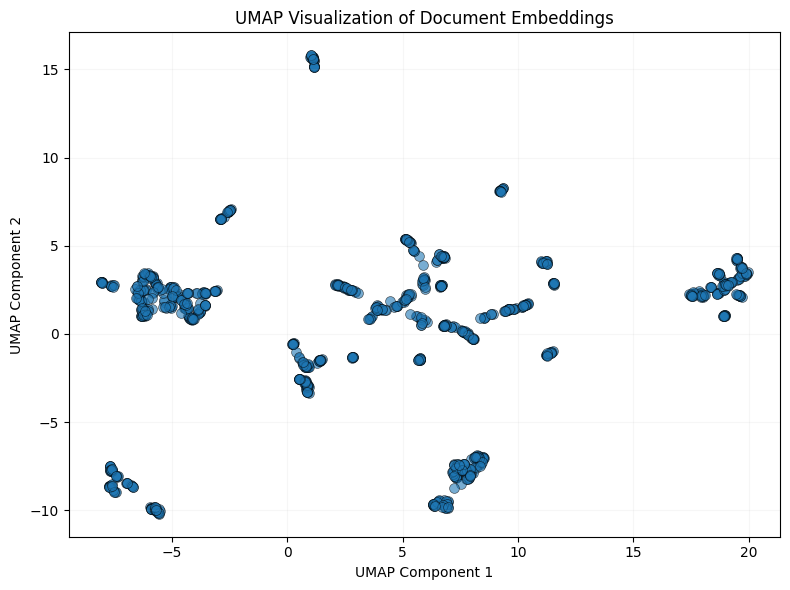

Visualized 1064 documents in 2D space
UMAP reduced dimensions from 3072 to 2


In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.title("UMAP Visualization of Document Embeddings")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

print(f"Visualized {len(X_2d)} documents in 2D space")
print(f"UMAP reduced dimensions from {X_array.shape[1]} to {X_2d.shape[1]}")

<h5> This is the method k-silhouette, to find the number of clusters that the data can be split into. </h5>

In [7]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def find_best_k_silhouette(X, k_min=2, k_max=20):
    """
    Choose number of clusters k using silhouette score.
    X: numpy array (n_samples, n_features), e.g. your doc_vectors_array (normalized).
    Returns: (best_k, scores_dict)
        best_k: int or None if not enough samples
        scores_dict: {k: silhouette_score}
    """
    n_docs = X.shape[0]
    if n_docs < k_min + 1:
        # not enough documents to evaluate multiple ks
        return None, {}

    scores = {}
    max_k = min(k_max, n_docs - 1)  # cannot have k >= n_docs

    for k in range(k_min, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)

        # use cosine with normalized embeddings
        score = silhouette_score(X, labels, metric="cosine")
        scores[k] = score
        print(f"k={k}, silhouette={score:.4f}")

    # pick k with highest silhouette score
    best_k = max(scores, key=scores.get)
    print(f"Best k by silhouette: {best_k} (score={scores[best_k]:.4f})")
    return best_k, scores


In [8]:
# Extract document vectors from all_results
doc_vectors = []
valid_docs = []

for doc in all_results:
    v = doc.get("doc_vector")
    if v is not None:
        doc_vectors.append(v)
        valid_docs.append(doc)

# Convert to numpy array
doc_vectors_array = np.array(doc_vectors, dtype="float32")

print(f"Number of documents with valid vectors: {len(doc_vectors_array)}")
print(f"Vector dimensionality: {doc_vectors_array.shape[1]}")

# Find best k using silhouette method
best_k, silhouette_scores = find_best_k_silhouette(
    doc_vectors_array,
    k_min=2,
    k_max=20
)

Number of documents with valid vectors: 1064
Vector dimensionality: 3072
k=2, silhouette=0.3708
k=3, silhouette=0.4151
k=4, silhouette=0.3237
k=5, silhouette=0.2642
k=6, silhouette=0.2745
k=7, silhouette=0.2954
k=8, silhouette=0.2886
k=9, silhouette=0.3003
k=10, silhouette=0.3104
k=11, silhouette=0.3158
k=12, silhouette=0.3282
k=13, silhouette=0.3526
k=14, silhouette=0.3447
k=15, silhouette=0.2793
k=16, silhouette=0.2843
k=17, silhouette=0.3698
k=18, silhouette=0.2775
k=19, silhouette=0.2960
k=20, silhouette=0.3835
Best k by silhouette: 3 (score=0.4151)


<h5> By using the discovered number of clusters, we perform the K-Means algorithm to assign each document a cluster. </h5>

In [ ]:
# Perform final clustering with best k
if best_k is not None:
    n_clusters = best_k
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(doc_vectors_array)
    
    # Assign cluster labels back to documents
    for i, doc in enumerate(valid_docs):
        doc['cluster'] = int(cluster_labels[i])
    
    print(f"Clustering complete with k={n_clusters}")
    print(f"Cluster distribution:")
    unique, counts = np.unique(cluster_labels, return_counts=True)
    for cluster_id, count in zip(unique, counts):
        print(f"  Cluster {cluster_id}: {count} documents")
else:
    print("Could not determine optimal number of clusters")

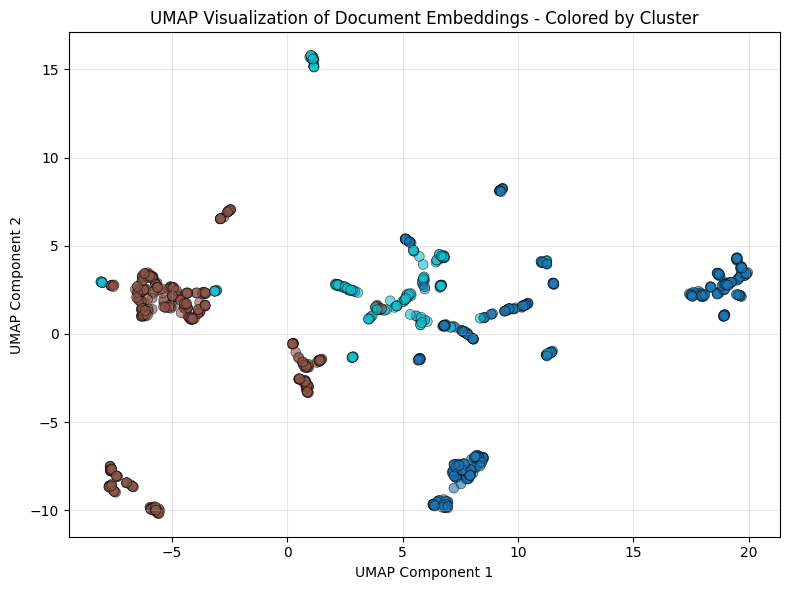


Cluster distribution in the visualization:
Cluster 0: 450 documents
Cluster 1: 416 documents
Cluster 2: 198 documents


In [10]:
# Visualize clusters using UMAP with different colors for each cluster
plt.figure(figsize=(8, 6))

# Get cluster labels only from documents with valid vectors
cluster_labels_for_plot = [doc['cluster'] for doc in valid_docs]

# Create scatter plot with different colors for each cluster
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels_for_plot, 
                     cmap='tab10', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

plt.title("UMAP Visualization of Document Embeddings - Colored by Cluster")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print cluster distribution
print("\nCluster distribution in the visualization:")
unique_clusters, counts = np.unique(cluster_labels_for_plot, return_counts=True)
for cluster_id, count in zip(unique_clusters, counts):
    print(f"Cluster {cluster_id}: {count} documents")

<h5> Sorting documents to folders based on the cluster belogining. </h5>

In [ ]:
# Create main clusters folder
clusters_main_dir = os.path.join("data_output", "clusters-03")
os.makedirs(clusters_main_dir, exist_ok=True)

# Create subfolders for each cluster and copy files
for cluster_id in range(n_clusters):
    # Create cluster subfolder
    cluster_dir = os.path.join(clusters_main_dir, f"cluster{cluster_id}")
    os.makedirs(cluster_dir, exist_ok=True)
    
    # Get documents in this cluster
    cluster_doc_count = 0
    for doc in all_results:
        if doc.get('cluster') == cluster_id:
            # Get original filename for destination
            original_filename = os.path.basename(doc['file'])
            
            # Source file path (use the full path from doc['file'])
            source_file = doc['file']
            
            # Destination file path
            dest_file = os.path.join(cluster_dir, original_filename)
            
            # Copy file to cluster folder
            if os.path.exists(source_file):
                shutil.copy2(source_file, dest_file)
                cluster_doc_count += 1
            else:
                print(f"Warning: File not found: {source_file}")
    
    print(f"Cluster {cluster_id}: {cluster_doc_count} files copied to {cluster_dir}")

print(f"All files organized into {clusters_main_dir}")